In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import itertools
import time
import seaborn as sns

df = pd.read_csv("Expend.csv")

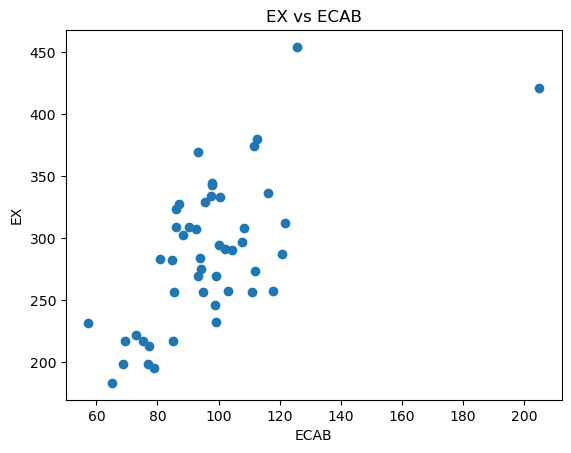

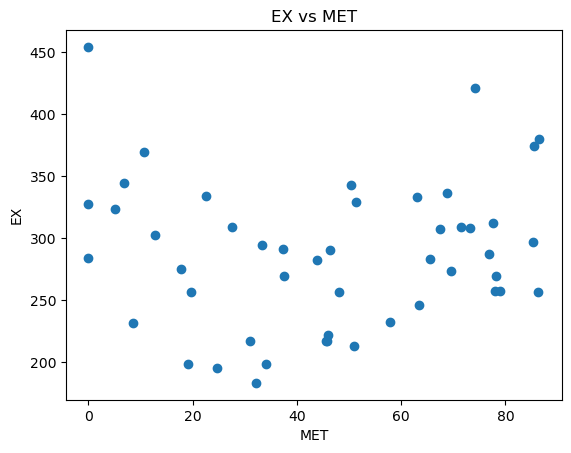

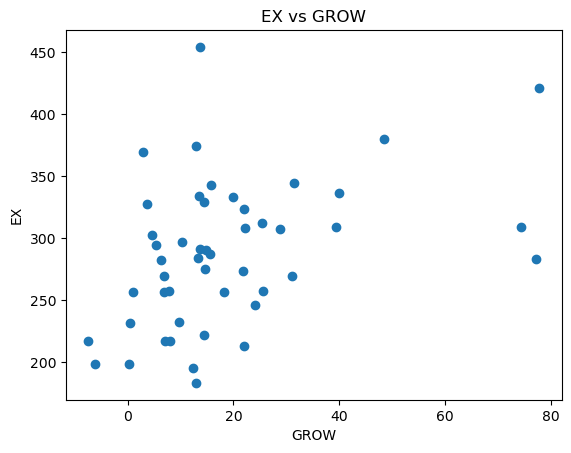

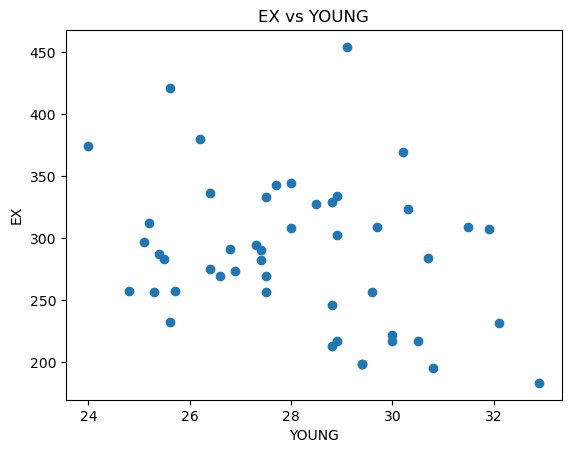

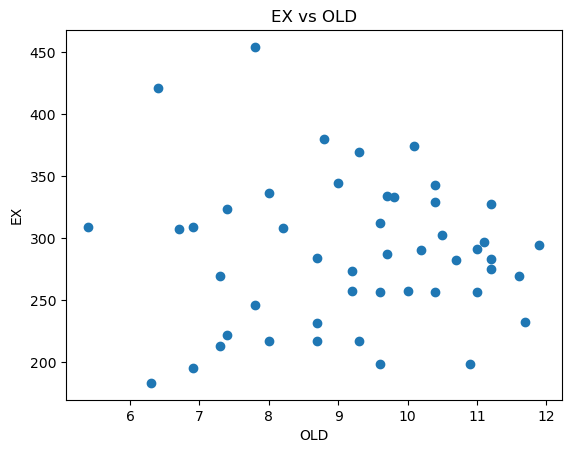

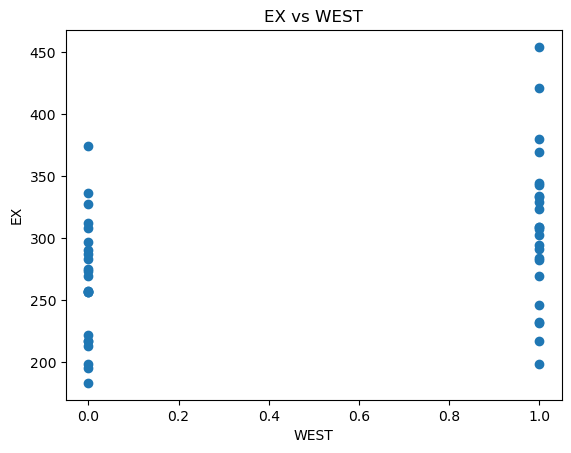

In [84]:
variables = ['ECAB','MET','GROW','YOUNG','OLD','WEST']

for var in variables:
    
    plt.figure()
    plt.scatter(df[var], df['EX'])
    plt.xlabel(var)
    plt.ylabel("EX")
    plt.title("EX vs " + var)
    plt.show()

In [85]:
X = df[['ECAB','MET','GROW','YOUNG','OLD','WEST']]
y = df['EX']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                     EX   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     10.22
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           6.63e-07
Time:                        11:57:11   Log-Likelihood:                -241.20
No. Observations:                  48   AIC:                             496.4
Df Residuals:                      41   BIC:                             509.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        356.1818    306.486      1.162      0.2

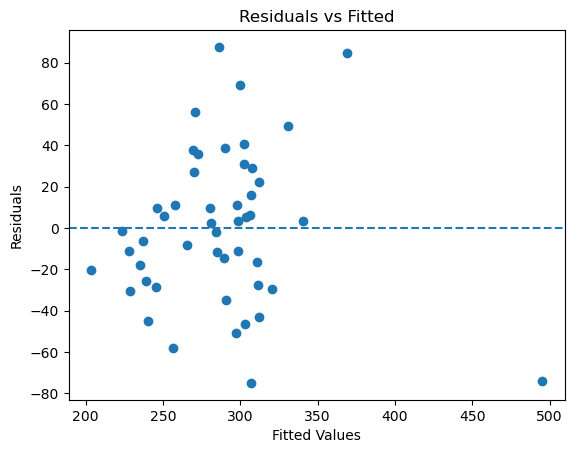

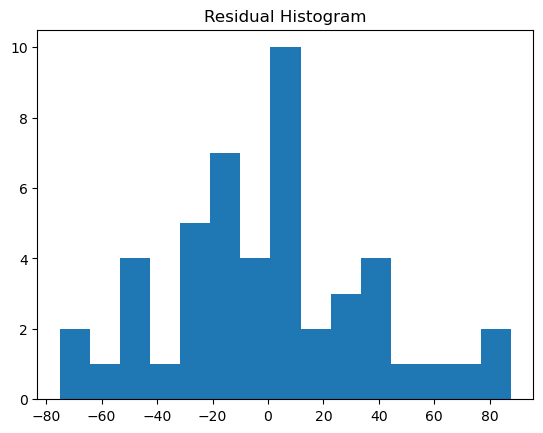

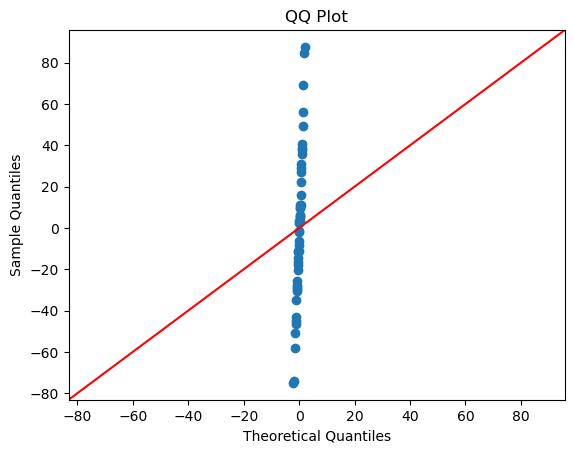

In [86]:
residuals = model.resid
fitted = model.fittedvalues

plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

plt.figure()
plt.hist(residuals, bins=15)
plt.title("Residual Histogram")
plt.show()

sm.qqplot(residuals, line='45')
plt.title("QQ Plot")
plt.show()

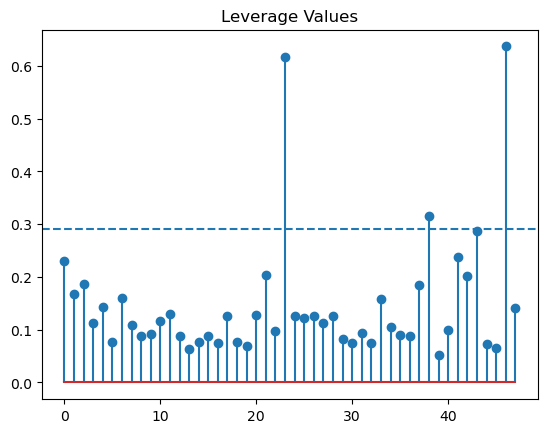

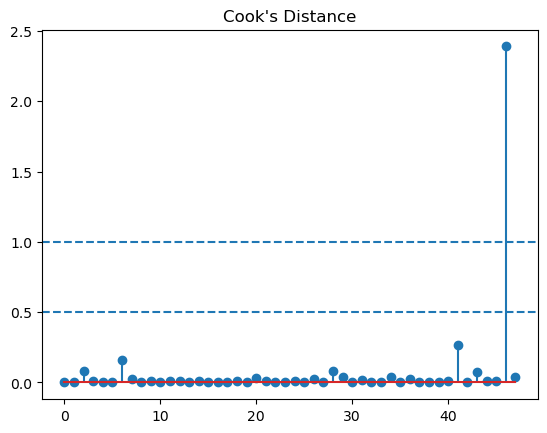

    Leverage  Cooks_Distance
46  0.636746        2.390120
41  0.238721        0.266361
6   0.160795        0.157853
28  0.126493        0.083985
2   0.186931        0.080649


In [87]:
influence = model.get_influence()

leverage = influence.hat_matrix_diag
cooks = influence.cooks_distance[0]

n = len(df)
p = X.shape[1] - 1

avg_leverage = (p + 1) / n
threshold = 2 * avg_leverage

plt.figure()
plt.stem(leverage)
plt.axhline(threshold, linestyle='--')
plt.title("Leverage Values")
plt.show()

plt.figure()
plt.stem(cooks)
plt.axhline(1, linestyle='--')
plt.axhline(0.5, linestyle='--')
plt.title("Cook's Distance")
plt.show()

df['Leverage'] = leverage
df['Cooks_Distance'] = cooks

print(df[['Leverage','Cooks_Distance']].sort_values(by='Cooks_Distance', ascending=False).head())

In [88]:
max_index = np.argmax(cooks)

print("Observation with largest Cook's Distance:")
print(df.iloc[max_index])

Observation with largest Cook's Distance:
EX                     421
ECAB                 205.0
MET                   74.2
GROW                  77.8
YOUNG                 25.6
OLD                    6.4
WEST                     1
STATE                   NV
Leverage          0.636746
Cooks_Distance     2.39012
Name: 46, dtype: object


In [89]:
df_new = df.drop(index=max_index)

X2 = df_new[['ECAB','MET','GROW','YOUNG','OLD','WEST']]
y2 = df_new['EX']

X2 = sm.add_constant(X2)

model2 = sm.OLS(y2, X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                     EX   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     12.56
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           6.52e-08
Time:                        11:57:11   Log-Likelihood:                -230.45
No. Observations:                  47   AIC:                             474.9
Df Residuals:                      40   BIC:                             487.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.0621    286.443      0.143      0.8

In [90]:
comparison = pd.DataFrame({
    "With Nevada": model.params,
    "Without Nevada": model2.params
})

print(comparison)

       With Nevada  Without Nevada
const   356.181848       41.062094
ECAB      1.418502        2.634938
MET      -0.660153       -0.677271
GROW      0.571590        0.867035
YOUNG    -6.674659       -0.266743
OLD      -1.855073        0.100994
WEST     35.472336       32.992673
